Dataset shape: (5000, 10)

First 5 rows:
        City  Age  Monthly_Income Education_Level Employment_Type  \
0    Lucknow   64          124641       Secondary      Unemployed   
1  Hyderabad   63          137267    Postgraduate         Private   
2     Jaipur   69           58517       Secondary      Government   
3    Chennai   36           39012       Secondary         Private   
4    Lucknow   30          147487       Secondary      Government   

   Digital_Usage_Hours  Household_Size   Area_Type  Govt_Scheme_Usage  \
0                 9.10               2       Urban                  1   
1                 5.68               1       Rural                  4   
2                 9.28               7       Rural                  3   
3                 5.94               4  Semi-Urban                  4   
4                 1.16               1       Urban                  0   

   Citizen_Segment  
0                1  
1                1  
2                1  
3                0  


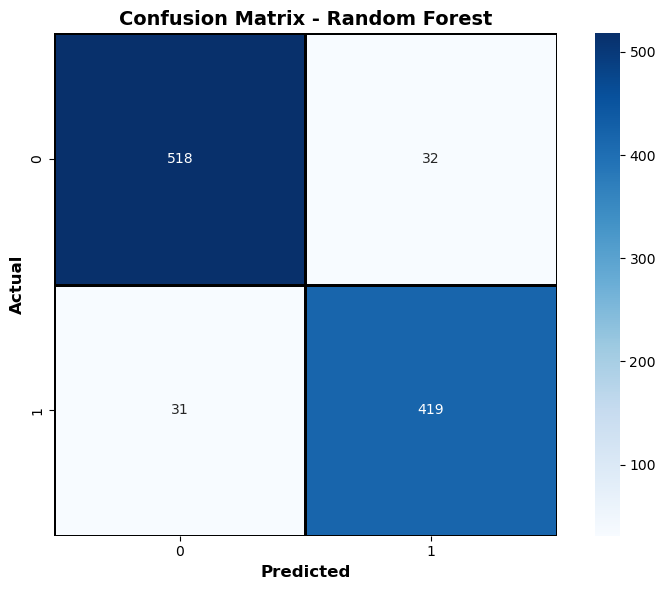

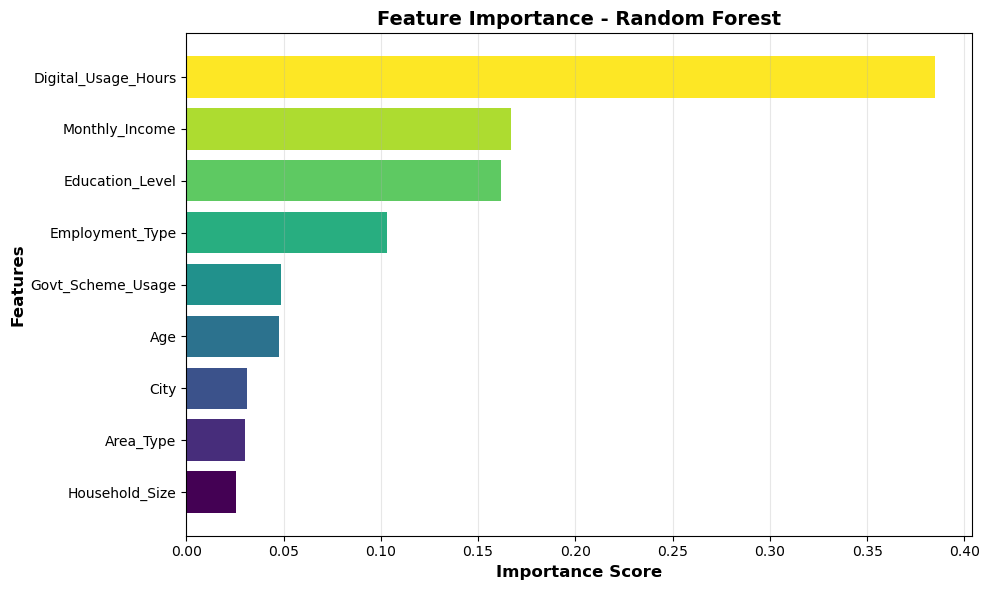

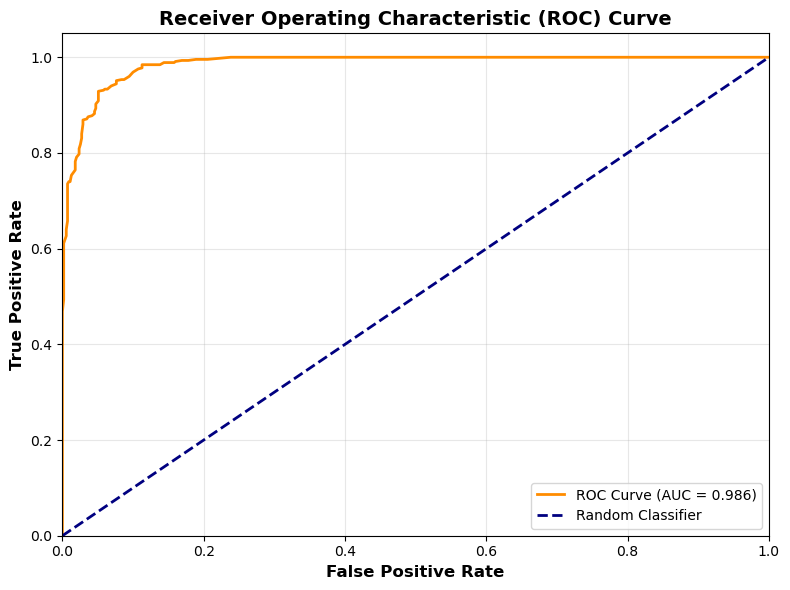

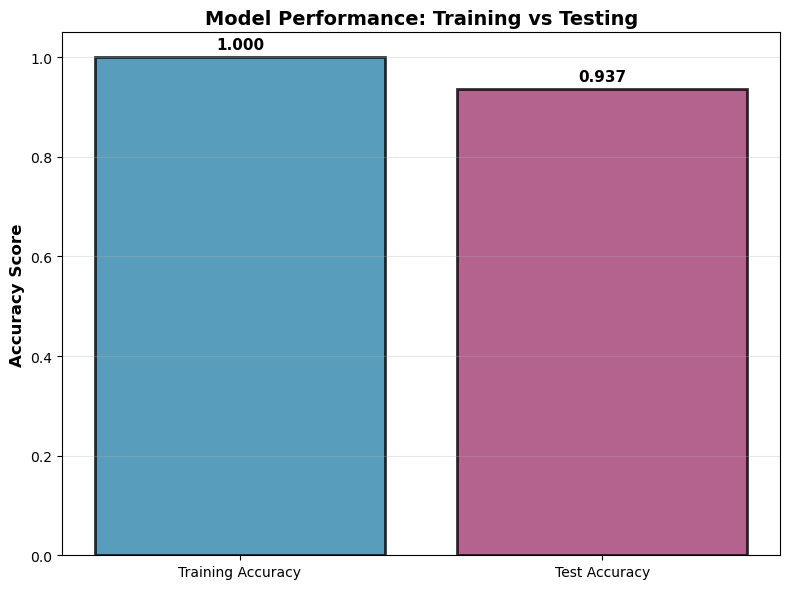

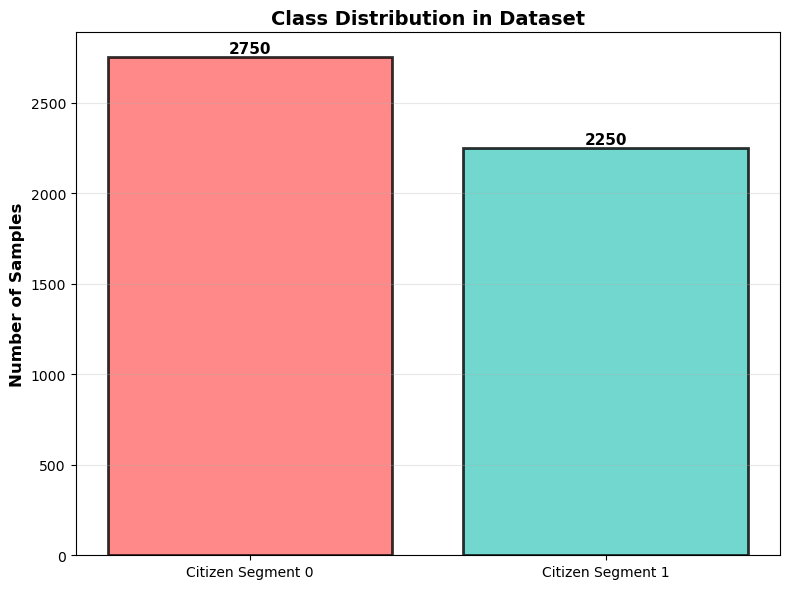

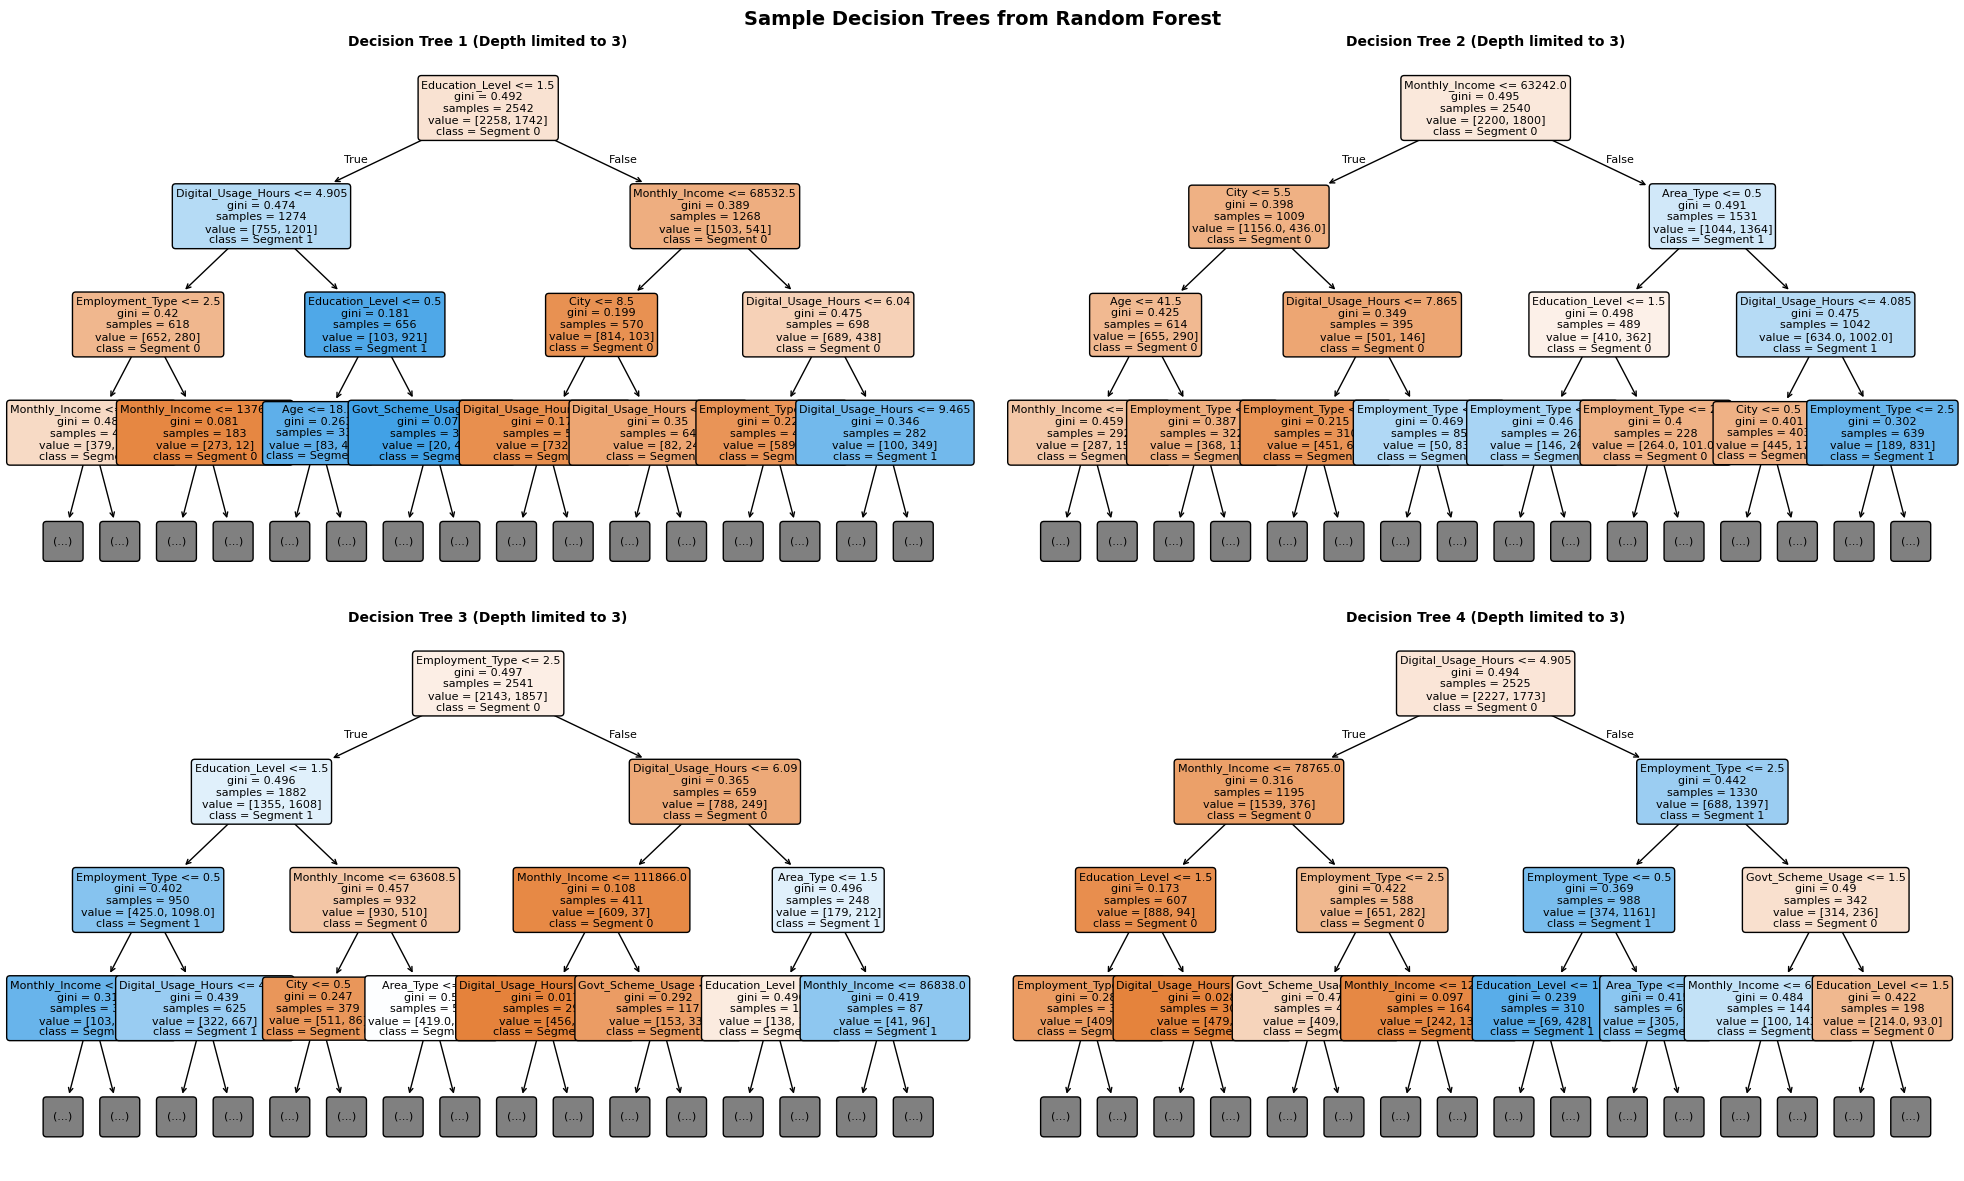


📊 Feature Importance Table:
            feature  importance
Digital_Usage_Hours    0.384808
     Monthly_Income    0.166861
    Education_Level    0.162003
    Employment_Type    0.103314
  Govt_Scheme_Usage    0.048641
                Age    0.047473
               City    0.031112
          Area_Type    0.030105
     Household_Size    0.025683


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('citizen.csv')

# Display basic info
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

# Check for missing values
print("\nMissing values:\n", df.isnull().sum())

# Encode categorical features
categorical_cols = ['City', 'Education_Level', 'Employment_Type', 'Area_Type']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Features and target
X = df.drop('Citizen_Segment', axis=1)
y = df['Citizen_Segment']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Accuracy: {accuracy:.4f}")
print("\n📋 Classification Report:\n", classification_report(y_test, y_pred))

# ============= GRAPH 1: Confusion Matrix =============
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
            square=True, linewidths=2, linecolor='black')
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============= GRAPH 2: Feature Importance (Bar Plot) =============
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(feature_importance)))
plt.barh(feature_importance['feature'], feature_importance['importance'], color=colors)
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ============= GRAPH 3: ROC Curve =============
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============= GRAPH 4: Training vs Test Accuracy Comparison =============
y_train_pred = rf.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)

plt.figure(figsize=(8, 6))
bars = plt.bar(['Training Accuracy', 'Test Accuracy'], [train_acc, accuracy], 
               color=['#2E86AB', '#A23B72'], alpha=0.8, edgecolor='black', linewidth=2)
plt.ylim([0, 1.05])
plt.ylabel('Accuracy Score', fontsize=12, fontweight='bold')
plt.title('Model Performance: Training vs Testing', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ============= GRAPH 5: Class Distribution (Check Imbalance) =============
plt.figure(figsize=(8, 6))
class_counts = y.value_counts()
colors = ['#FF6B6B', '#4ECDC4']
bars = plt.bar(['Citizen Segment 0', 'Citizen Segment 1'], class_counts.values, 
               color=colors, alpha=0.8, edgecolor='black', linewidth=2)
plt.ylabel('Number of Samples', fontsize=12, fontweight='bold')
plt.title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ============= GRAPH 6: Trees in Random Forest (First few trees) =============
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 12))
for i in range(min(4, len(rf.estimators_))):
    plt.subplot(2, 2, i+1)
    plot_tree(rf.estimators_[i], 
              feature_names=X.columns, 
              class_names=['Segment 0', 'Segment 1'],
              filled=True, 
              rounded=True,
              fontsize=8,
              max_depth=3)  # Limit depth for better visibility
    plt.title(f'Decision Tree {i+1} (Depth limited to 3)', fontsize=10, fontweight='bold')
plt.suptitle('Sample Decision Trees from Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============= Print Feature Importance Table =============
print("\n📊 Feature Importance Table:")
print(feature_importance.sort_values('importance', ascending=False).to_string(index=False))